# Sentiment Analysis of Nigerian Public Reaction to the Naira/USD Exchange Rate

## Overview

The Nigerian Naira has seen significant movement against the US Dollar in recent months, sparking widespread public debate on social media. This notebook analyses the sentiment of 52 manually collected tweets about the Naira/USD exchange rate.

**Note:** The 52 demo tweets were manually collected from Twitter/X in early 2026 and are not a statistically representative sample. They are a demonstration of sentiment analysis on real Nigerian Twitter language about a specific economic event.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import sys

sys.path.insert(0, os.path.abspath('..'))

from src.model import load_model, predict, load_demo_model, predict_demo
from src.preprocess import clean_text

plt.rcParams['figure.figsize'] = (10, 5)
sns.set_style('whitegrid')

## 1. Demo Tweets

The 52 tweets were manually collected from Twitter/X by searching for terms related to the Naira/USD exchange rate in early 2026, a period when the Naira had been appreciating against the dollar. The tweets represent a cross section of Nigerian public opinion. Some express hope, some skepticism, some are purely analytical.

We apply the same cleaning function used during training to strip URLs, mentions, hashtags and punctuation before running predictions.

In [2]:
demo_df = pd.read_excel('../demo/tweets.xlsx')
demo_df.columns = ['tweet']
demo_df['tweet'] = demo_df['tweet'].apply(clean_text)
demo_df = demo_df[demo_df['tweet'].str.strip() != ''].reset_index(drop=True)

print(f'Total tweets: {len(demo_df)}')
print('\nSample tweets:')
for i, tweet in enumerate(demo_df['tweet'].head(5), 1):
    print(f'{i}. {tweet}\n')

Total tweets: 52

Sample tweets:
1. you people aint getting the gist naira is nt appreciating to dollar is dollar dats dropping value

2. id be so happy if the dollar hit 1100 to the naira in few months need that so bad

3. i really want the naira to go back to at least 500 naira to a dollar

4. the naira weakened to 1359 per dollar after the central bank of nigeria reduced the interest rate to 265

5. dangote was launching his refinery shares and he created a naira gaining strength over dollar narrative so everyone can buy his shares so he can use your funds to scale up demand yet some of you believed him because he is a billionaire hell no most billionaires lie more than poor people as a matter of fact if they dont lie to the public most of their business will collapse what keeps them running is the secrets they know the masses dont and they keep it away from you so their empire keeps thriving



## 2. Using AfriBERTa

We start with the model we built, AfriBERTa fine-tuned on the NaijaSenti PCM dataset. This model was trained specifically on Nigerian Pidgin sentiment classification and achieved an `F1 macro` of `0.74` on the NaijaSenti test set.

The expectation is that it should handle Nigerian Twitter language well given it was trained on Nigerian Pidgin tweets.

In [3]:
print('Loading AfriBERTa model...')
model, tokenizer = load_model()
print('Model loaded successfully')

tweets = demo_df['tweet'].tolist()
results = predict(tweets, model, tokenizer)
results_df = pd.DataFrame(results)

print('\nAfriBERTa predictions:')
print(results_df['sentiment'].value_counts())
print(f'\nAverage confidence: {results_df["confidence"].mean():.4f}')

Loading AfriBERTa model...


Loading weights:   0%|          | 0/169 [00:00<?, ?it/s]

Model loaded successfully

AfriBERTa predictions:
sentiment
negative    51
positive     1
Name: count, dtype: int64

Average confidence: 0.9176


### Something looks off

51 out of 52 tweets classified as negative with an average confidence of 0.92. Before accepting this result, it is worth asking whether this genuinely reflects the data or whether something is wrong.

Let's look at the tweets the model classified as negative with the highest confidence and ask whether those labels feel right.

In [4]:
high_conf_neg = results_df[results_df['sentiment'] == 'negative'].sort_values('confidence', ascending=False)

print('HIGH CONFIDENCE NEGATIVE PREDICTIONS')
print('=' * 70)
for _, row in high_conf_neg.head(8).iterrows():
    print(f'Confidence: {row["confidence"]}')
    print(f'Tweet: {row["tweet"]}')
    print()

HIGH CONFIDENCE NEGATIVE PREDICTIONS
Confidence: 0.9789
Tweet: satisfying nigerian is the hardest job on earth when you ask a nigerian to list 5 characteristics of a failed government one of the first 3 things heshe will say is the value of naira against the dollar everyday on x someone is saying 1 used to be now its 2k this leaders have failed us now you have a government plugging all the leakages thats making our currency weak in the fx market nigerians have started complaining at this point we should just agree that no one wants a good or bad governance we only want situations that aligns with or promote our personal interests dollar is going to by eoy prepare your mind

Confidence: 0.9785
Tweet: you actually dont need to be conflicted if naira continues to rise it means what you would normally send 100k to naija for would now cost less maybe 60k because the value of the currency is now stronger

Confidence: 0.9759
Tweet: 4h and after 2031 some one if not u will also start defending

### Observation

Looking at the high confidence negative predictions, several of them are not straightforwardly negative. Tweets like "No noise. No propaganda. He met foreign reserves at $33b and raised them to $49b in under 3 years... Cardoso: The Headmaster. The best CBN gov. ever" are clearly positive about the CBN governor's performance, yet the model classified them as negative with high confidence.

This is a sign of a deeper problem. The model is not simply making classification errors, it is systematically misreading an entire category of tweets and there is need to understand why.

## 3. Diagnosing the Problem
To understand the systematic misclassification, we need to compare the training data to the demo tweets.

**The training data (NaijaSenti PCM)** consists of short, casual, emotionally direct Nigerian Pidgin expressions. Examples from the training set look like:
- "they should stop abeg na me dey suffer am"
- "this your body na killer"
- "belle dey pain me breast dey pain me"

**The demo tweets** are a completely different kind of text:
- Long, analytical economic commentary
- Formal or semi-formal English with some pidgin mixed in
- Discussing CBN policy, exchange rate mechanics, political accountability
- Often expressing nuanced or mixed views rather than clear emotions

This mismatch is a typical case of **domain shift**. The model is applied to a domain it was never trained on. The model learned to associate certain pidgin patterns with sentiment but those patterns do not appear in formal economic commentary. Faced with unfamiliar text structure, it defaults to negative which was the majority class in training.

The high confidence scores make this worse, the model is not uncertain, it is confidently wrong. This happens because the text is so different from anything in training that the model's probability estimates are unreliable.

The right response is to find a model that was trained on text more similar to what we are analysing.

## 4. Cardiff RoBERTa

Cardiff NLP's `twitter-roberta-base-sentiment-latest` is a RoBERTa model fine-tuned on 58 million English tweets for sentiment classification. Unlike AfriBERTa which was specialised for Nigerian Pidgin, this model was trained on a much broader range of Twitter language including formal commentary, political discussion, and economic analysis.

It also supports three classes; negative, neutral, and positive, which is more appropriate for our tweets since many of them are analytical rather than emotionally charged in either direction.

In [5]:
print('Loading Cardiff RoBERTa model...')
demo_model, demo_tokenizer = load_demo_model()
print('Model loaded successfully')

demo_results = predict_demo(tweets, demo_model, demo_tokenizer)
demo_results_df = pd.DataFrame(demo_results)

print('\nCardiff RoBERTa predictions:')
print(demo_results_df['sentiment'].value_counts())
print(f'\nAverage confidence: {demo_results_df["confidence"].mean():.4f}')

Loading Cardiff RoBERTa model...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.embeddings.position_ids | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.pooler.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Model loaded successfully



Cardiff RoBERTa predictions:
sentiment
negative    28
neutral     21
positive     3
Name: count, dtype: int64

Average confidence: 0.6883


### Observation

The Cardiff model produces a more believable distribution: `28 negative, 21 neutral, 3 positive`, and the average confidence dropped from `0.92` to `0.69`. The lower confidence is actually a sign of better calibration. The model is appropriately uncertain about ambiguous tweets rather than confidently forcing everything into one class.

The large neutral class makes intuitive sense. Many of the collected tweets are analytical observations about exchange rate mechanics, CBN policy, or economic theory. They are not expressing personal positive or negative sentiment, they are explaining or commenting. Neutral is the correct label for that kind of text.

We proceed with the Cardiff predictions for the rest of the analysis.

## 5. Analysis of Results

With the more appropriate model selected, we now analyse the sentiment distribution and examine specific examples from each class.

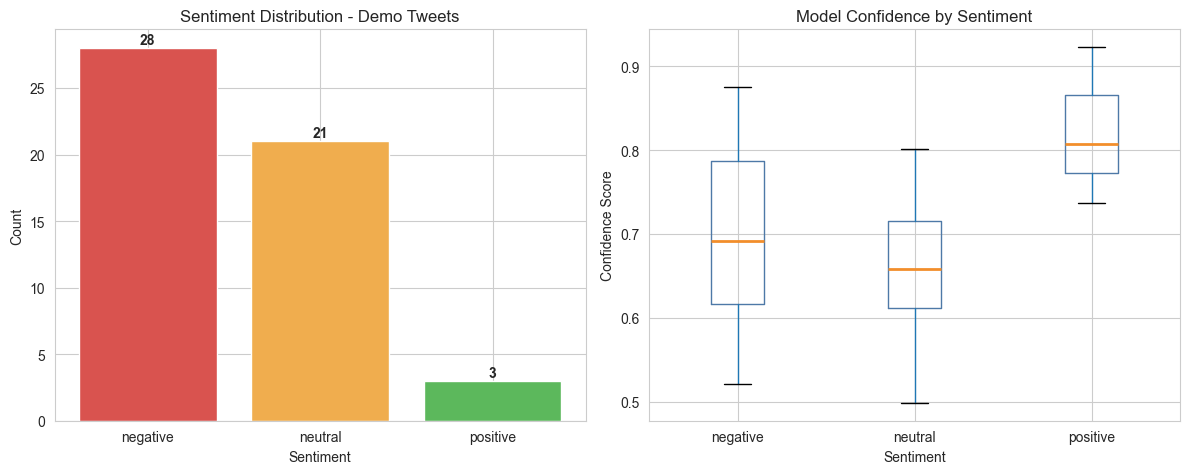

In [6]:
# sentiment distribution chart
sentiment_counts = demo_results_df['sentiment'].value_counts()
colors = {'negative': '#d9534f', 'neutral': '#f0ad4e', 'positive': '#5cb85c'}
bar_colors = [colors[s] for s in sentiment_counts.index]

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# bar chart
axes[0].bar(sentiment_counts.index, sentiment_counts.values, color=bar_colors)
axes[0].set_title('Sentiment Distribution - Demo Tweets')
axes[0].set_xlabel('Sentiment')
axes[0].set_ylabel('Count')
for i, v in enumerate(sentiment_counts.values):
    axes[0].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

# confidence by sentiment
demo_results_df.boxplot(column='confidence', by='sentiment', ax=axes[1],
                        boxprops=dict(color='#4e79a7'),
                        medianprops=dict(color='#f28e2b', linewidth=2))
axes[1].set_title('Model Confidence by Sentiment')
axes[1].set_xlabel('Sentiment')
axes[1].set_ylabel('Confidence Score')
plt.suptitle('')

plt.tight_layout()
plt.savefig('../outputs/demo_sentiment_distribution.png', dpi=150)
plt.show()

In [7]:
# sample tweets per sentiment class
for sentiment in ['negative', 'neutral', 'positive']:
    subset = demo_results_df[demo_results_df['sentiment'] == sentiment]
    print(f'{sentiment.upper()} TWEETS (showing 3)')
    print('=' * 70)
    for _, row in subset.head(3).iterrows():
        print(f'Confidence: {row["confidence"]}')
        print(f'Tweet: {row["tweet"]}')
        print()
    print()

NEGATIVE TWEETS (showing 3)
Confidence: 0.674
Tweet: you people aint getting the gist naira is nt appreciating to dollar is dollar dats dropping value

Confidence: 0.8632
Tweet: i cant believe nigerians living in nigeria earning in dollars are angry that dollar to naira is reducing this is weird

Confidence: 0.8755
Tweet: if you fell for that dollar naira price discovery gimmick then im truly not sorry for you ser esp those who hastily withdrew funds pls take some time to understand the performance of across board then draw your personal conclusions the govt preys on instances like this to cajole the vulnerable people


NEUTRAL TWEETS (showing 3)
Confidence: 0.4984
Tweet: i really want the naira to go back to at least 500 naira to a dollar

Confidence: 0.7606
Tweet: the naira weakened to 1359 per dollar after the central bank of nigeria reduced the interest rate to 265

Confidence: 0.6279
Tweet: dangote was launching his refinery shares and he created a naira gaining strength over doll

### Observation

The sentiment distribution tells an interesting story about Nigerian public discourse around the Naira appreciation.

The dominant sentiment is negative (28 tweets, 54%). This reflects the general skepticism on Nigerian Twitter, even when reporting positive economic news, people question whether the gains are real, sustainable, or beneficial to ordinary Nigerians. Tweets reference the Dangote narrative, CBN intervention, and the disconnect between exchange rate improvements and the cost of living.

The neutral class (21 tweets, 40%) is largely made up of analytical commentary, people explaining exchange rate mechanics, CBN policy decisions, and macroeconomic context without expressing a personal sentiment. This is a distinctive feature of financial Twitter where education and analysis often dominate over emotional reactions.

Positive tweets are rare (3 tweets, 6%). The few positive ones tend to praise specific actors like the CBN governor or express personal hope about the exchange rate reaching a target. The scarcity of positive sentiment despite objectively good economic news (Naira appreciating) is itself a finding, it suggests deep-rooted skepticism about whether currency gains translate to real improvements in living standards.

## 6. Limitations and Conclusions

### Limitations

**Sample size and selection bias.** 52 manually collected tweets is a very small sample. The tweets were collected by searching specific terms which means they are not a random sample of all Naira-related discourse. The results should not be generalised beyond this specific snapshot.

**Model limitations.** Cardiff RoBERTa was trained on English tweets and may still struggle with heavy pidgin, code-switching, or Nigerian cultural references. Sarcasm in particular remains difficult for any sentiment model to detect reliably.

**Domain mismatch (AfriBERTa).** Our fine-tuned AfriBERTa model, despite performing well on the NaijaSenti test set (F1 macro 0.74), was not suited for formal economic commentary. This highlights an important real-world lesson, a model that performs well on its training domain can fail significantly when applied to a different domain even within the same language.

**No ground truth labels.** We do not have human-annotated labels for the demo tweets, so we cannot formally measure how accurate the Cardiff predictions are on this specific dataset.

### Conclusions

Despite the limitations, the analysis surfaces a genuine finding. Nigerian public sentiment around the Naira appreciation is predominantly negative or skeptical, even as the exchange rate improves. The disconnect between macro economic indicators and public sentiment reflects a deeper mistrust: **people are not convinced that currency gains will translate to cheaper goods, lower fuel prices, or improved living standards.**

The large neutral class also suggests that financial Twitter in Nigeria is not purely emotional, a significant portion of discourse is analytical and educational, which is not captured well by simple positive/negative sentiment models.